# Ein Flug zum Mond mit Runge-Kutta

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Zunächst definieren wir die notwendigen Konstanten:  
$\mu_E = G_N M_E \,$ ist der Gravitationsparameter der Erde  
$\mu_M = G_N M_N \,$ ist der Gravitationsparameter des Mondes   
$R_E$ ist der Erdradius  
$r_{ME}$ ist der Abstand Erde-Mond  

Alle Einheiten sind in Metern und Sekunden!

In [119]:
mu_E = 3.986004418e14
mu_M = 4.9048695e12
R_E = 6371e3
r_ME = 384400e3

Der Orbit des Mondes wird analytisch berechnet. Hierzu betrachten wir das Kräftegleichgewicht im Orbit  

Gravitative Anziehung der Erde: $ F_{G} = \frac{G_N M_E m}{r^2} =\frac{\mu_E m}{r^2} $
Zentrifugalkraft im Orbit: $F_z = m \omega^2 r$  

Wobei $m$ die Masse des umkreisenden Objektes ist (hier der Mond), $r = r_{ME}$ und $\omega = \frac{v}{r}$ ist die Winkelgeschwindigkeit im Orbit

$\Rightarrow \omega = \sqrt{\frac{\mu_E}{r^3}}$

$T_M$ beschreibt die Zeit (in Sekunden) die der Mond braucht um die Erde zu umkreisen  
--> Was ist der Unterschied zu Mondphasen?

In [120]:
omega_M = np.sqrt(mu_E / r_ME**3)
T_M = 2*np.pi / omega_M

T_M/(60*60*24)

np.float64(27.45189357205398)

Wir befinden uns in der Ebene, die durch die Erde, den Mond und seine Umlaufbahn aufgespannt wird. Der Ursprung des Koordinatensystems beschreibt den Erdmittelpunkt.

In [121]:
def mond_position(t, theta_0):
    " Der Anfangsparameter theta_0 gibt an wie der Mond zu unserer Rakete gerade steht!"
    theta = omega_M * t
    return np.array([r_ME*np.cos(theta+ theta_0), r_ME*np.sin(theta+ theta_0)])

def beschleunigung_grav(r_t, t, theta_0):
    " r_t ist der aktuelle Ortsvektor der Testladung, t der Zeitpunkt den wir für die Position des Mondes brauchen"
    r_vec = r_t 
    r_norm = np.linalg.norm(r_vec) # Länge des Vektors
    a_earth = -mu_E * r_vec / r_norm**3 # Kraft durch Erdanziehung
    
    r_m = mond_position(t, theta_0)
    r_rel = r_t - r_m  # Vektor Mond-Rakete
    r_rel_norm = np.linalg.norm(r_rel)
    a_mond = -mu_M * r_rel / r_rel_norm**3
    return a_earth + a_mond

Jetzt implementieren wir einen Runge-Kutta 4 Timestepper

In [122]:
def RK4_zumMond(dt, Tmax, r0, v0, t0):
    times = np.arange(0.0, Tmax + dt, dt)
    trajektorie = np.zeros((len(times), 2))
    geschwindigkeit = np.zeros((len(times), 2))
    mond_pos = np.zeros((len(times), 2))

    r = r0
    v = v0
    
    for i, t in enumerate(times):
        trajektorie[i] = r
        geschwindigkeit[i] = v
        mond_pos[i] = mond_position(t, t0)

        # k1
        a1 = beschleunigung_grav(r, t, t0)
        k1_v = a1 * dt
        k1_r = v * dt
        # k2
        a2 = beschleunigung_grav(r + 0.5*k1_r, t + 0.5*dt, t0)
        k2_v = a2 * dt
        k2_r = (v + 0.5*k1_v) * dt
        # k3
        a3 = beschleunigung_grav(r + 0.5*k2_r, t + 0.5*dt, t0)
        k3_v = a3 * dt
        k3_r = (v + 0.5*k2_v) * dt
        # k4
        a4 = beschleunigung_grav(r + k3_r, t + dt, t0)
        k4_v = a4 * dt
        k4_r = (v + k3_v) * dt
    
        r = r + (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0
        v = v + (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0
        
    return times, trajektorie, geschwindigkeit, mond_pos

Nun berechnen wir die Geschwindigkeit im *lower earth orbit*.   

Daher definieren wir die Vektoren $r_0, v_0$.

In [123]:
h_leo = 200e3              # Höhe über der ErdoberflächeNun berechnen wir die Geschwindigkeit im *lower earth orbit*.  

r_leo = R_E + h_leo
v_leo = np.sqrt(mu_E / r_leo) # Allgemeine Formel für Geschwindingkeit im Erdorbit!

theta_0 = np.pi/2 

r_0 = np.array([r_leo, 0.0])
v_0 = np.array([0.0, v_leo])

Mit diesen Bedingungen bleibt die Rakete im Erdorbit!
Testen wir es doch mal

In [128]:
T_max = T_M  # Wir rechnen für die Dauer einer Mondumkreisung              
dt =  30.0 # Zeitchrittgröße 1 min

t, s, v, mond = RK4_zumMond(dt, T_max, r_0, v_0, theta_0)

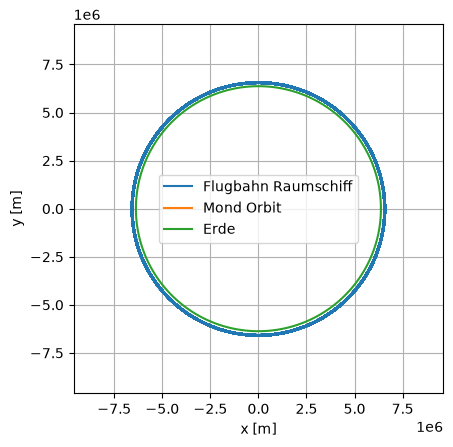

In [129]:
plt.gca().set_aspect('equal')
plt.plot(s[:,0], s[:,1], label='Flugbahn Raumschiff')
plt.plot(mond[:,0], mond[:,1], label='Mond Orbit')

# show Earth as a circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_E*np.cos(theta), R_E*np.sin(theta), label='Erde')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.xlim([-0.025*r_ME, 0.025*r_ME])
plt.ylim([-0.025*r_ME, 0.025*r_ME])
plt.legend()
plt.grid(True)
plt.show()

In [138]:
a_trans = 0.5 * (r_leo + r_ME)
v_perigee_trans = np.sqrt(mu_E * (2/r_leo - 1/a_trans)) 
delta_v = v_perigee_trans - v_leo

theta_0 = np.pi/2 #+0.17

r_0 = np.array([r_leo, 0.0])
v_0 = np.array([0.0, v_leo + delta_v])

T_max = 60*60*24 *7           
dt = 30.0 # Zeitschrittgröße 1 min

t, s1, v1, mond1 = RK4_zumMond(dt, T_max, r_0, v_0, theta_0)

dist_to_moon = np.linalg.norm(s1-mond1, axis=1)

min_idx = np.argmin(dist_to_moon)
min_distanz = dist_to_moon[min_idx]
time_of_min = t[min_idx]
nähester_Punkt = min_distanz 

print(nähester_Punkt)
print(r_ME)


41718974.90468863
384400000.0


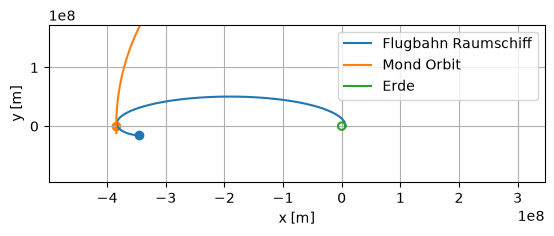

In [139]:
plt.gca().set_aspect('equal')
plt.plot(s1[:,0], s1[:,1], label='Flugbahn Raumschiff')
plt.plot(mond1[:,0], mond1[:,1], label='Mond Orbit')

# show Earth as a circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_E*np.cos(theta), R_E*np.sin(theta), label='Erde')

# mark Moon position at closest approach
plt.scatter([s1[min_idx,0]], [s1[min_idx,1]])
plt.scatter([mond1[min_idx,0]], [mond1[min_idx,1]])

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.xlim([-1.3*r_ME, 0.9*r_ME])
plt.ylim([-0.25*r_ME, 0.45*r_ME])
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

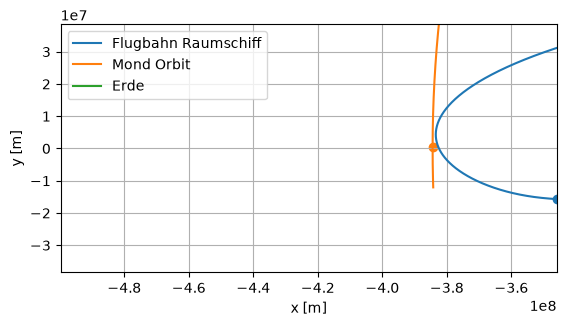

In [140]:
plt.gca().set_aspect('equal')
plt.plot(s1[:,0], s1[:,1], label='Flugbahn Raumschiff')
plt.plot(mond1[:,0], mond1[:,1], label='Mond Orbit')

# show Earth as a circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_E*np.cos(theta), R_E*np.sin(theta), label='Erde')

# mark Moon position at closest approach
plt.scatter([s1[min_idx,0]], [s1[min_idx,1]])
plt.scatter([mond1[min_idx,0]], [mond1[min_idx,1]])

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.xlim([-1.3*r_ME, -0.9*r_ME])
plt.ylim([-0.1*r_ME, 0.1*r_ME])
plt.legend()
plt.grid(True)
plt.show()

In [141]:
a_trans = 0.5 * (r_leo + r_ME)
v_perigee_trans = np.sqrt(mu_E * (2/r_leo - 1/a_trans)) 
delta_v = v_perigee_trans + 0.001

theta_0 = np.pi/2 

r_0 = np.array([r_leo, 0.0])
v_0 = np.array([0.0, v_leo + delta_v])

T_max = 60*60*24 *7           
dt = 60.0 # Zeitschrittgröße 1 min

t2, s2, v2, mond2 = RK4_zumMond(dt, T_max, r_0, v_0, theta_0 + 0.11)
t3, s3, v3, mond3 = RK4_zumMond(dt, T_max, r_0, v_0, theta_0 + 0.135)
t4, s4, v4, mond4 = RK4_zumMond(dt, T_max, r_0, v_0, 0.0)

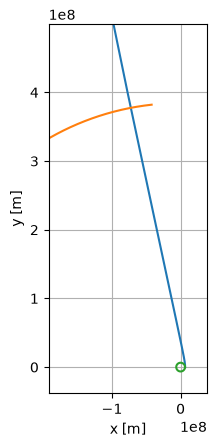

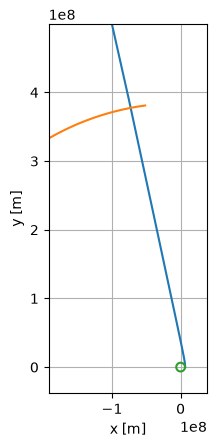

In [145]:
plt.gca().set_aspect('equal')
plt.plot(s2[:,0], s2[:,1], label='Flugbahn Raumschiff')
plt.plot(mond2[:,0], mond2[:,1], label='Mond Orbit')

# show Earth as a circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_E*np.cos(theta), R_E*np.sin(theta), label='Erde')


# mark Moon position at closest approach
#plt.scatter([s2[min_idx,0]], [s2[min_idx,1]])
#plt.scatter([mond2[min_idx,0]], [mond2[min_idx,1]])

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.xlim([-0.5*r_ME, 0.1*r_ME])
plt.ylim([-0.1*r_ME, 1.3*r_ME])
#plt.legend()
plt.grid(True)
plt.show()

plt.gca().set_aspect('equal')
plt.plot(s3[:,0], s3[:,1], label='Flugbahn Raumschiff')
plt.plot(mond3[:,0], mond3[:,1], label='Mond Orbit')

# show Earth as a circle
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(R_E*np.cos(theta), R_E*np.sin(theta), label='Erde')


# mark Moon position at closest approach
#plt.scatter([s3[min_idx,0]], [s3[min_idx,1]])
#plt.scatter([mond3[min_idx,0]], [mond3[min_idx,1]])

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.xlim([-0.5*r_ME, 0.1*r_ME])
plt.ylim([-0.1*r_ME, 1.3*r_ME])
#plt.legend()
plt.grid(True)
plt.show()

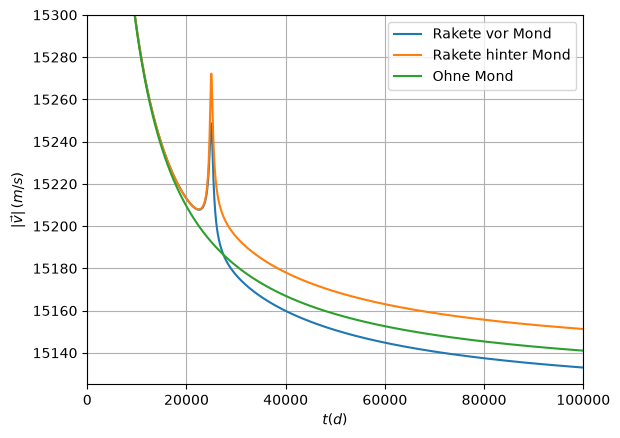

In [146]:
plt.plot(t2, np.linalg.norm(v2, axis=1), label='Rakete vor Mond')
plt.plot(t3, np.linalg.norm(v3, axis=1), label='Rakete hinter Mond')
plt.plot(t4, np.linalg.norm(v4, axis=1), label='Ohne Mond')
plt.xlabel(r'$t (d)$')
plt.ylabel(r'$|\vec v|\, (m/s)$')
plt.ylim([15125,15300])
plt.xlim([0,100000])
plt.legend()
plt.grid()
plt.show()